# Laboratorio 6 — Semana 9: Transfer Learning y Fine-Tuning

**Curso:** Deep Learning | **Valor:** 4% | **Individual**

---

## Descripcion general

En este laboratorio usted va a adaptar ResNet-18, preentrenada en ImageNet, para clasificar imágenes de CIFAR-10. Implementará tres estrategias de transfer learning de complejidad creciente y comparará su comportamiento experimentalmente.

**Partes del laboratorio:**

- **Bloque 1 (20 pts):** Feature extraction — congelar todo el backbone
- **Bloque 2 (20 pts):** Fine-tuning parcial — descongelar `layer4`
- **Bloque 3 (20 pts):** Fine-tuning completo con learning rate diferencial
- **Bloque 4 (15 pts):** Análisis de representaciones aprendidas
- **Bloque 5 (25 pts):** Preguntas de análisis

**Reglas:**
- Use `torchvision.models.resnet18(weights='IMAGENET1K_V1')` para cargar el modelo preentrenado.
- No use `nn.DataParallel` ni ninguna abstracción de entrenamiento de alto nivel.
- Puede usar `loss.backward()` y `optimizer.step()` normalmente.
- La celda de verificación al final califica los 75 puntos de código.

---
## Bloque 0: Imports, datos y configuración (dado, no modificar)

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.models as models
import torchvision.transforms as T
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt
import random

torch.manual_seed(42)
random.seed(42)
np.random.seed(42)
print(f'PyTorch: {torch.__version__}')
print(f'torchvision: {torchvision.__version__}')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {DEVICE}')


PyTorch: 2.13.0+cu130
torchvision: 0.28.0+cu130
Dispositivo: cuda


In [2]:
# Reproducibilidad en GPU (no altera resultados en CPU)
#
# Con backbone congelado (Bloques 1 y 2) el backward se corta antes de los
# kernels de convolucion y el resultado ya es determinista. En el Bloque 3 se
# entrena la red completa, y los kernels de wgrad de cuDNN acumulan con
# atomics: el orden de suma cambia entre corridas y dos ejecuciones con el
# mismo seed dan accuracies distintas. Estas tres lineas fuerzan algoritmos
# deterministas; medido en RTX 5070 Ti el costo es nulo (17.8s vs 18.4s).
import os
os.environ.setdefault('CUBLAS_WORKSPACE_CONFIG', ':4096:8')
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True, warn_only=True)

print(f'Determinismo activado. cudnn.deterministic={torch.backends.cudnn.deterministic}')


Determinismo activado. cudnn.deterministic=True


In [3]:
# Transformaciones para CIFAR-10 con ResNet18
# ResNet espera imagenes normalizadas con la media y std de ImageNet
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

transform_train = T.Compose([
    T.Resize(64),              # ResNet funciona mejor con imagenes > 32px
    T.RandomHorizontalFlip(),  # augmentation basica
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

transform_val = T.Compose([
    T.Resize(64),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Descargar CIFAR-10
# La primera vez descarga ~170MB desde internet
cifar_train_full = torchvision.datasets.CIFAR10(
    root='./data', train=True,  download=True, transform=transform_train)
cifar_val_full   = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_val)

# Usar subconjunto para que el laboratorio sea rapido en CPU
# 2000 de entrenamiento, 500 de validacion
torch.manual_seed(42)
train_idx = torch.randperm(len(cifar_train_full))[:2000].tolist()
val_idx   = torch.randperm(len(cifar_val_full))[:500].tolist()

train_dataset = Subset(cifar_train_full, train_idx)
val_dataset   = Subset(cifar_val_full,   val_idx)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False, num_workers=0)

CLASSES = cifar_train_full.classes
print(f'Clases CIFAR-10: {CLASSES}')
print(f'Train: {len(train_dataset)} imagenes, Val: {len(val_dataset)} imagenes')
print(f'Batches por epoca (train): {len(train_loader)}')


Clases CIFAR-10: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Train: 2000 imagenes, Val: 500 imagenes
Batches por epoca (train): 32


In [4]:
# Funcion de entrenamiento dada (no modificar)
def train_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0; correct = 0; total = 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(X)
        loss = F.cross_entropy(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y)
        correct += (logits.argmax(1) == y).sum().item()
        total += len(y)
    return total_loss/total, correct/total

def eval_epoch(model, loader, device):
    model.eval()
    total_loss = 0; correct = 0; total = 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            loss = F.cross_entropy(logits, y)
            total_loss += loss.item() * len(y)
            correct += (logits.argmax(1) == y).sum().item()
            total += len(y)
    return total_loss/total, correct/total

def plot_curves(histories, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    for name, h in histories.items():
        ax1.plot(h['val_loss'], label=name)
        ax2.plot(h['val_acc'],  label=name)
    ax1.set_title(f'{title} — Val Loss'); ax1.set_xlabel('Epoca')
    ax2.set_title(f'{title} — Val Acc');  ax2.set_xlabel('Epoca')
    ax1.legend(); ax2.legend()
    plt.tight_layout()
    plt.savefig(f'{title.replace(" ","_")}.png', dpi=110)
    plt.show()

print('Funciones de entrenamiento listas.')


Funciones de entrenamiento listas.


---
## Bloque 1: Feature extraction — congelar el backbone (20 pts)

Cargue ResNet-18 con pesos preentrenados en ImageNet. Congele **todos** los parámetros del backbone y reemplace la capa `fc` final por una nueva capa lineal de 10 salidas (las 10 clases de CIFAR-10).

**Requisitos:**
- Todos los parámetros excepto la nueva `fc` deben tener `requires_grad=False`
- La nueva `fc` debe tener `requires_grad=True`
- El número total de parámetros entrenables debe ser exactamente `512 * 10 + 10 = 5130`

**Criterio de convergencia:** la accuracy de validación debe superar 40% en 10 épocas (con pesos ImageNet el modelo ya tiene buenas representaciones).

In [5]:
def build_feature_extractor(num_classes=10):
    """
    Construye ResNet-18 para feature extraction.

    Pasos:
    1. Cargar ResNet-18 con pesos preentrenados:
       models.resnet18(weights='IMAGENET1K_V1')
    2. Congelar todos los parametros:
       for param in model.parameters(): param.requires_grad = False
    3. Reemplazar model.fc con nn.Linear(512, num_classes)
       (la nueva capa tiene requires_grad=True por defecto)

    Retorna el modelo modificado.
    """
    # ====================
    # SU CODIGO AQUI
    # ====================
    # 1. Cargar ResNet-18 preentrenado en ImageNet
    model = models.resnet18(weights='IMAGENET1K_V1')

    # 2. Congelar TODOS los parámetros del backbone
    for param in model.parameters():
        param.requires_grad = False

    # 3. Reemplazar la capa fc final (512 → num_classes)
    #    nn.Linear crea la capa con requires_grad=True por defecto
    model.fc = nn.Linear(512, num_classes)

    return model


model_fe = build_feature_extractor().to(DEVICE)

# Diagnostico de parametros
n_trainable = sum(p.numel() for p in model_fe.parameters() if p.requires_grad)
n_frozen    = sum(p.numel() for p in model_fe.parameters() if not p.requires_grad)
print(f'Parametros entrenables: {n_trainable:,}  (esperado: 5,130)')
print(f'Parametros congelados:  {n_frozen:,}  (esperado: 11,176,512)')

# Verificar que solo la nueva cabeza tiene gradiente
print('\nCapas con requires_grad=True:')
for name, param in model_fe.named_parameters():
    if param.requires_grad:
        print(f'  {name}: {param.shape}')


Parametros entrenables: 5,130  (esperado: 5,130)
Parametros congelados:  11,176,512  (esperado: 11,176,512)

Capas con requires_grad=True:
  fc.weight: torch.Size([10, 512])
  fc.bias: torch.Size([10])


In [6]:
# Entrenamiento feature extraction
N_EPOCHS_FE = 10
optimizer_fe = torch.optim.Adam(model_fe.parameters(), lr=1e-3)

history_fe = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}

for epoch in range(N_EPOCHS_FE):
    tr_loss, tr_acc = train_epoch(model_fe, train_loader, optimizer_fe, DEVICE)
    vl_loss, vl_acc = eval_epoch(model_fe, val_loader, DEVICE)
    history_fe['train_loss'].append(tr_loss)
    history_fe['train_acc'].append(tr_acc)
    history_fe['val_loss'].append(vl_loss)
    history_fe['val_acc'].append(vl_acc)
    if (epoch+1) % 2 == 0:
        print(f'Ep {epoch+1:2d}: '
              f'train_loss={tr_loss:.3f}, train_acc={tr_acc:.2%}, '
              f'val_loss={vl_loss:.3f}, val_acc={vl_acc:.2%}')

print(f'\nVal accuracy final: {history_fe["val_acc"][-1]:.2%}')


Ep  2: train_loss=1.501, train_acc=49.70%, val_loss=1.455, val_acc=52.20%
Ep  4: train_loss=1.192, train_acc=60.60%, val_loss=1.306, val_acc=55.20%
Ep  6: train_loss=1.072, train_acc=65.25%, val_loss=1.273, val_acc=59.20%
Ep  8: train_loss=1.009, train_acc=66.20%, val_loss=1.278, val_acc=58.80%
Ep 10: train_loss=0.943, train_acc=68.75%, val_loss=1.288, val_acc=60.80%

Val accuracy final: 60.80%


In [7]:
# Verificacion Bloque 1
_resultados = {}
try:
    assert model_fe is not None, 'model_fe no definido'
    n_tr = sum(p.numel() for p in model_fe.parameters() if p.requires_grad)
    n_fr = sum(p.numel() for p in model_fe.parameters() if not p.requires_grad)
    assert n_tr == 5130, f'Entrenables incorrectos: {n_tr} (esperado 5130)'
    assert n_fr == 11176512, f'Congelados incorrectos: {n_fr}'
    backbone_grad = any(
        p.requires_grad
        for name,p in model_fe.named_parameters() if 'fc' not in name)
    assert not backbone_grad, 'El backbone no debe tener requires_grad=True'
    best_val = max(history_fe['val_acc'])
    assert best_val >= 0.35, \
        f'Val acc {best_val:.2%} < 35%. Verifique que uso pesos preentrenados.'
    _resultados['b1'] = True
    print(f'BLOQUE 1: CORRECTO  (val_acc={best_val:.2%})')
except AssertionError as e:
    _resultados['b1'] = False
    print(f'BLOQUE 1: INCORRECTO\n  {e}')


BLOQUE 1: CORRECTO  (val_acc=62.40%)


---
## Bloque 2: Fine-tuning parcial — descongelar `layer4` (20 pts)

Cargue ResNet-18 con pesos preentrenados. Congele todo excepto `layer4` y la nueva cabeza `fc`.

**Estructura de ResNet-18:** `conv1` → `bn1` → `layer1` → `layer2` → `layer3` → `layer4` → `avgpool` → `fc`

**Requisitos:**
- `layer1`, `layer2`, `layer3`, `conv1`, `bn1`: `requires_grad=False`
- `layer4` y `fc`: `requires_grad=True`
- Los parámetros entrenables deben estar entre 8.3M y 8.5M

**Criterio:** la accuracy de validación debe superar la del Bloque 1.

In [8]:
def build_partial_finetune(num_classes=10):
    """
    ResNet-18 con fine-tuning parcial: solo layer4 y fc son entrenables.

    Pasos:
    1. Cargar con pesos preentrenados
    2. Congelar todos los parametros
    3. Descongelar layer4:
       for param in model.layer4.parameters(): param.requires_grad = True
    4. Reemplazar model.fc con nn.Linear(512, num_classes)

    Retorna el modelo modificado.
    """
    
    model = models.resnet18(weights='IMAGENET1K_V1')
    for param in model.parameters():
        param.requires_grad = False
    for param in model.layer4.parameters():
        param.requires_grad = True
    model.fc = nn.Linear(512, num_classes)
    return model

model_pf = build_partial_finetune().to(DEVICE)

n_trainable_pf = sum(p.numel() for p in model_pf.parameters() if p.requires_grad)
n_frozen_pf    = sum(p.numel() for p in model_pf.parameters() if not p.requires_grad)
print(f'Entrenables: {n_trainable_pf:,}  (esperado: ~8,398,858)')
print(f'Congelados:  {n_frozen_pf:,}  (esperado: ~2,782,784)')

# Verificar que layer1 NO tiene grad y layer4 SI tiene grad
print(f'layer1 requires_grad: {any(p.requires_grad for p in model_pf.layer1.parameters())}')
print(f'layer4 requires_grad: {all(p.requires_grad for p in model_pf.layer4.parameters())}')


Entrenables: 8,398,858  (esperado: ~8,398,858)
Congelados:  2,782,784  (esperado: ~2,782,784)
layer1 requires_grad: False
layer4 requires_grad: True


In [9]:
# Entrenamiento fine-tuning parcial
N_EPOCHS_PF = 10
# Nota: lr mas bajo que feature extraction para no destruir pesos preentrenados
optimizer_pf = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_pf.parameters()),
    lr=1e-4
)

history_pf = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}

for epoch in range(N_EPOCHS_PF):
    tr_loss, tr_acc = train_epoch(model_pf, train_loader, optimizer_pf, DEVICE)
    vl_loss, vl_acc = eval_epoch(model_pf, val_loader, DEVICE)
    history_pf['train_loss'].append(tr_loss)
    history_pf['train_acc'].append(tr_acc)
    history_pf['val_loss'].append(vl_loss)
    history_pf['val_acc'].append(vl_acc)
    if (epoch+1) % 2 == 0:
        print(f'Ep {epoch+1:2d}: '
              f'train_loss={tr_loss:.3f}, train_acc={tr_acc:.2%}, '
              f'val_loss={vl_loss:.3f}, val_acc={vl_acc:.2%}')

print(f'\nVal accuracy final FE:  {history_fe["val_acc"][-1]:.2%}')
print(f'Val accuracy final PF:  {history_pf["val_acc"][-1]:.2%}')


Ep  2: train_loss=0.813, train_acc=76.25%, val_loss=0.973, val_acc=68.80%
Ep  4: train_loss=0.326, train_acc=92.00%, val_loss=0.850, val_acc=71.80%
Ep  6: train_loss=0.133, train_acc=98.30%, val_loss=0.836, val_acc=72.20%
Ep  8: train_loss=0.065, train_acc=99.40%, val_loss=0.787, val_acc=74.80%
Ep 10: train_loss=0.034, train_acc=99.95%, val_loss=0.804, val_acc=73.60%

Val accuracy final FE:  60.80%
Val accuracy final PF:  73.60%


In [10]:
# Verificacion Bloque 2
try:
    assert model_pf is not None, 'model_pf no definido'
    l4_grad = all(p.requires_grad for p in model_pf.layer4.parameters())
    l1_no   = not any(p.requires_grad for p in model_pf.layer1.parameters())
    l2_no   = not any(p.requires_grad for p in model_pf.layer2.parameters())
    l3_no   = not any(p.requires_grad for p in model_pf.layer3.parameters())
    assert l4_grad, 'layer4 debe tener requires_grad=True'
    assert l1_no and l2_no and l3_no, 'layer1/2/3 deben estar congeladas'
    n_tr_pf = sum(p.numel() for p in model_pf.parameters() if p.requires_grad)
    assert 8_000_000 < n_tr_pf < 9_000_000, \
        f'Entrenables fuera de rango: {n_tr_pf:,}'
    best_pf = max(history_pf['val_acc'])
    assert best_pf >= 0.40, \
        f'Val acc {best_pf:.2%} < 40%. Verifique la implementacion.'
    _resultados['b2'] = True
    print(f'BLOQUE 2: CORRECTO  (val_acc={best_pf:.2%})')
except AssertionError as e:
    _resultados['b2'] = False
    print(f'BLOQUE 2: INCORRECTO\n  {e}')


BLOQUE 2: CORRECTO  (val_acc=74.80%)


---
## Bloque 3: Fine-tuning completo con learning rate diferencial (20 pts)

Desbloquee todos los parámetros de ResNet-18 pero asigne un learning rate distinto a cada grupo de capas. Las capas tempranas deben recibir un learning rate mucho menor porque ya tienen representaciones útiles que no queremos modificar agresivamente.

**Learning rates por grupo:**

| Grupo | Capas | Learning rate |
|---|---|---|
| `stem` | `conv1`, `bn1` | `1e-6` |
| `layer1` | Primer bloque residual | `1e-5` |
| `layer2` | Segundo bloque residual | `5e-5` |
| `layer3` | Tercer bloque residual | `1e-4` |
| `layer4` | Cuarto bloque residual | `5e-4` |
| `head` | Nueva `fc` | `1e-3` |

**Implementación:** cree una lista de diccionarios con claves `'params'` y `'lr'` y pásela al optimizador:
```python
optimizer = torch.optim.Adam([
    {'params': model.layer1.parameters(), 'lr': 1e-5},
    ...
])
```

**Requisito crítico:** todos los parámetros del modelo deben estar cubiertos por exactamente un grupo.

In [11]:
def build_full_finetune(num_classes=10):
    """
    ResNet-18 con todos los parametros descongelados.
    Solo reemplaza la cabeza fc.
    """

    model = models.resnet18(weights='IMAGENET1K_V1')
    for param in model.parameters():
        param.requires_grad = True
    model.fc = nn.Linear(512, num_classes)
    return model

def make_param_groups(model):
    """
    Crea la lista de grupos de parametros con learning rates diferenciales.

    Retorna una lista de dicts con claves 'params' y 'lr'.
    El orden debe ser de menor a mayor learning rate.

    Grupos requeridos:
    - stem (conv1 + bn1): lr = 1e-6
    - layer1: lr = 1e-5
    - layer2: lr = 5e-5
    - layer3: lr = 1e-4
    - layer4: lr = 5e-4
    - head (fc): lr = 1e-3

    IMPORTANTE: list(model.layerX.parameters()) convierte el generador a lista.
    No use el mismo objeto en dos grupos.
    """
    
    return [
        {'params': list(model.conv1.parameters()) + list(model.bn1.parameters()), 'lr': 1e-6},
        {'params': list(model.layer1.parameters()), 'lr': 1e-5},
        {'params': list(model.layer2.parameters()), 'lr': 5e-5},
        {'params': list(model.layer3.parameters()), 'lr': 1e-4},
        {'params': list(model.layer4.parameters()), 'lr': 5e-4},
        {'params': list(model.fc.parameters()), 'lr': 1e-3},
    ]

model_dlr = build_full_finetune().to(DEVICE)
param_groups = make_param_groups(model_dlr)
optimizer_dlr = torch.optim.Adam(param_groups)

# Diagnostico
print('Grupos de parametros:')
for i, g in enumerate(optimizer_dlr.param_groups):
    n = sum(p.numel() for p in g['params'])
    print(f'  Grupo {i}: {n:>10,} params, lr={g["lr"]}')

total_in_groups = sum(p.numel() for g in param_groups for p in g['params'])
total_model     = sum(p.numel() for p in model_dlr.parameters())
print(f'\nTotal en grupos: {total_in_groups:,}')
print(f'Total modelo:    {total_model:,}')
print(f'Cubierto: {total_in_groups == total_model}')


Grupos de parametros:
  Grupo 0:      9,536 params, lr=1e-06
  Grupo 1:    147,968 params, lr=1e-05
  Grupo 2:    525,568 params, lr=5e-05
  Grupo 3:  2,099,712 params, lr=0.0001
  Grupo 4:  8,393,728 params, lr=0.0005
  Grupo 5:      5,130 params, lr=0.001

Total en grupos: 11,181,642
Total modelo:    11,181,642
Cubierto: True


Ep  2: train_loss=0.443, train_acc=84.80%, val_loss=0.761, val_acc=75.20%
Ep  4: train_loss=0.120, train_acc=96.70%, val_loss=0.864, val_acc=77.00%
Ep  6: train_loss=0.072, train_acc=98.15%, val_loss=0.886, val_acc=78.00%
Ep  8: train_loss=0.037, train_acc=99.10%, val_loss=1.005, val_acc=76.00%
Ep 10: train_loss=0.039, train_acc=98.90%, val_loss=1.060, val_acc=75.40%

=== Comparacion final ===
Feature extraction:  62.40%
Fine-tuning parcial: 74.80%
LR diferencial:      78.60%


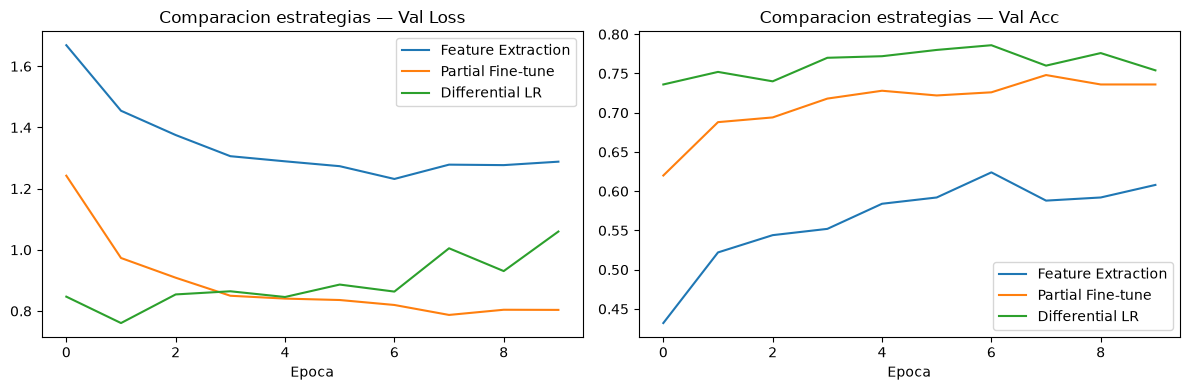

In [12]:
# Entrenamiento fine-tuning completo con LR diferencial
N_EPOCHS_DLR = 10
history_dlr = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}

for epoch in range(N_EPOCHS_DLR):
    tr_loss, tr_acc = train_epoch(model_dlr, train_loader, optimizer_dlr, DEVICE)
    vl_loss, vl_acc = eval_epoch(model_dlr, val_loader, DEVICE)
    history_dlr['train_loss'].append(tr_loss)
    history_dlr['train_acc'].append(tr_acc)
    history_dlr['val_loss'].append(vl_loss)
    history_dlr['val_acc'].append(vl_acc)
    if (epoch+1) % 2 == 0:
        print(f'Ep {epoch+1:2d}: '
              f'train_loss={tr_loss:.3f}, train_acc={tr_acc:.2%}, '
              f'val_loss={vl_loss:.3f}, val_acc={vl_acc:.2%}')

# Comparacion de las tres estrategias
print('\n=== Comparacion final ===')
print(f'Feature extraction:  {max(history_fe["val_acc"]):.2%}')
print(f'Fine-tuning parcial: {max(history_pf["val_acc"]):.2%}')
print(f'LR diferencial:      {max(history_dlr["val_acc"]):.2%}')

plot_curves(
    {'Feature Extraction': history_fe,
     'Partial Fine-tune':  history_pf,
     'Differential LR':   history_dlr},
    'Comparacion estrategias'
)


In [13]:
# Verificacion Bloque 3
try:
    assert model_dlr is not None, 'model_dlr no definido'
    assert param_groups is not None, 'param_groups no definido'
    # LRs estrictamente crecientes
    lrs = [g['lr'] for g in optimizer_dlr.param_groups]
    assert all(lrs[i] < lrs[i+1] for i in range(len(lrs)-1)), \
        f'LRs no son crecientes: {lrs}'
    # Todos los parametros cubiertos
    total_in = sum(p.numel() for g in param_groups for p in g['params'])
    total_m  = sum(p.numel() for p in model_dlr.parameters())
    assert total_in == total_m, \
        f'Parametros sin cubrir: {total_m-total_in:,}'
    # LR correcto para la cabeza
    head_lr = optimizer_dlr.param_groups[-1]['lr']
    assert abs(head_lr - 1e-3) < 1e-8, \
        f'LR de la cabeza incorrecto: {head_lr}'
    # LR correcto para stem
    stem_lr = optimizer_dlr.param_groups[0]['lr']
    assert abs(stem_lr - 1e-6) < 1e-10, \
        f'LR del stem incorrecto: {stem_lr}'
    best_dlr = max(history_dlr['val_acc'])
    assert best_dlr >= 0.40, \
        f'Val acc {best_dlr:.2%} < 40%.'
    _resultados['b3'] = True
    print(f'BLOQUE 3: CORRECTO  (val_acc={best_dlr:.2%}, LRs={lrs})')
except AssertionError as e:
    _resultados['b3'] = False
    print(f'BLOQUE 3: INCORRECTO\n  {e}')


BLOQUE 3: CORRECTO  (val_acc=78.60%, LRs=[1e-06, 1e-05, 5e-05, 0.0001, 0.0005, 0.001])


---
## Bloque 4: Análisis de representaciones (15 pts)

Extraiga los embeddings del backbone (antes de la capa `fc`) para 500 imágenes de validación usando los tres modelos entrenados. Compare cuantitativamente la calidad de las representaciones aprendidas.

El backbone de ResNet-18 produce embeddings de dimensión 512 (la salida de `avgpool` antes de `fc`).

**Métrica de separabilidad:** ratio entre la varianza inter-clase y la varianza intra-clase en el espacio de embeddings:

$$\text{sep} = \frac{\sum_k n_k \|\boldsymbol{\mu}_k - \boldsymbol{\mu}\|^2}{\sum_k \sum_{i: y_i=k} \|\mathbf{h}_i - \boldsymbol{\mu}_k\|^2}$$

Donde $\boldsymbol{\mu}_k$ es el centroide de la clase $k$, $\boldsymbol{\mu}$ es el centroide global y $n_k$ es el número de ejemplos de la clase $k$. Un ratio mayor indica representaciones más separables.

In [14]:
def extract_embeddings(model, loader, device, max_samples=500):
    """
    Extrae los embeddings del backbone de ResNet-18 (antes de fc).

    Parámetros
    ----------
    model   : ResNet-18 modificado
    loader  : DataLoader de validacion
    device  : dispositivo
    max_samples : cuantos ejemplos extraer como maximo

    Retorna
    -------
    embeddings : Tensor (N, 512)
    labels     : Tensor (N,)

    Pasos:
    1. Construir backbone = nn.Sequential(*list(model.children())[:-1])
       Esto elimina la capa fc y conserva hasta avgpool inclusive.
    2. En modo eval() y sin gradientes, pasar cada batch por backbone.
    3. Aplicar .squeeze(-1).squeeze(-1) para eliminar dimensiones espaciales.
       La salida de avgpool es (B, 512, 1, 1) y debe quedar (B, 512).
    4. Acumular embeddings y labels hasta max_samples.
    """
    # ====================
    # SU CODIGO AQUI
    # ====================
    # 1. Backbone = todo el modelo menos la ultima capa (fc).
    #    children() de ResNet-18: conv1, bn1, relu, maxpool, layer1..layer4,
    #    avgpool, fc  ->  [:-1] conserva hasta avgpool inclusive.
    backbone = nn.Sequential(*list(model.children())[:-1]).to(device)
    backbone.eval()

    embeddings, labels = [], []
    n = 0

    # 2. Inferencia sin gradientes
    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)

            # 3. (B, 512, 1, 1) -> (B, 512)
            h = backbone(X).squeeze(-1).squeeze(-1)

            # 4. Acumular sin pasarse de max_samples
            take = min(len(y), max_samples - n)
            embeddings.append(h[:take].cpu())
            labels.append(y[:take].cpu())
            n += take
            if n >= max_samples:
                break

    return torch.cat(embeddings), torch.cat(labels)

# Extraer embeddings de los tres modelos
emb_fe,  lab_fe  = extract_embeddings(model_fe,  val_loader, DEVICE)
emb_pf,  lab_pf  = extract_embeddings(model_pf,  val_loader, DEVICE)
emb_dlr, lab_dlr = extract_embeddings(model_dlr, val_loader, DEVICE)

print(f'Embeddings FE:  {emb_fe.shape}')
print(f'Embeddings PF:  {emb_pf.shape}')
print(f'Embeddings DLR: {emb_dlr.shape}')


Embeddings FE:  torch.Size([500, 512])
Embeddings PF:  torch.Size([500, 512])
Embeddings DLR: torch.Size([500, 512])


In [15]:
def separability_ratio(embeddings, labels):
    """
    Calcula el ratio de separabilidad inter-clase / intra-clase.

    Parámetros
    ----------
    embeddings : Tensor (N, d)
    labels     : Tensor (N,)

    Retorna
    -------
    ratio : float — mayor es mejor separacion

    Pasos:
    1. Calcular centroide global: mu = embeddings.mean(0)
    2. Para cada clase k: calcular centroide mu_k y n_k
    3. Varianza inter: sum_k n_k * ||mu_k - mu||^2
    4. Varianza intra: sum_k sum_{i:y_i=k} ||h_i - mu_k||^2
    5. Retornar inter / intra
    """
    # ====================
    # SU CODIGO AQUI
    # ====================
    # 1. Centroide global
    mu = embeddings.mean(0)

    # device=... para que tambien funcione si los embeddings vienen en GPU
    inter = torch.zeros((), dtype=embeddings.dtype, device=embeddings.device)
    intra = torch.zeros((), dtype=embeddings.dtype, device=embeddings.device)

    # 2-4. Recorrer solo las clases presentes (evita dividir entre 0 si falta alguna)
    for k in labels.unique():
        Xk   = embeddings[labels == k]      # (n_k, d)
        n_k  = Xk.shape[0]
        mu_k = Xk.mean(0)

        inter += n_k * (mu_k - mu).pow(2).sum()   # n_k * ||mu_k - mu||^2
        intra += (Xk - mu_k).pow(2).sum()         # sum_i ||h_i - mu_k||^2

    # 5. Ratio (Fisher): mayor = clases mas separadas respecto a su dispersion interna
    return (inter / intra).item()

sep_fe  = separability_ratio(emb_fe,  lab_fe)
sep_pf  = separability_ratio(emb_pf,  lab_pf)
sep_dlr = separability_ratio(emb_dlr, lab_dlr)

print('Ratio de separabilidad (mayor = mejor):')
print(f'  Feature extraction:  {sep_fe:.4f}')
print(f'  Fine-tuning parcial: {sep_pf:.4f}')
print(f'  LR diferencial:      {sep_dlr:.4f}')


Ratio de separabilidad (mayor = mejor):
  Feature extraction:  0.0580
  Fine-tuning parcial: 0.2124
  LR diferencial:      0.7141


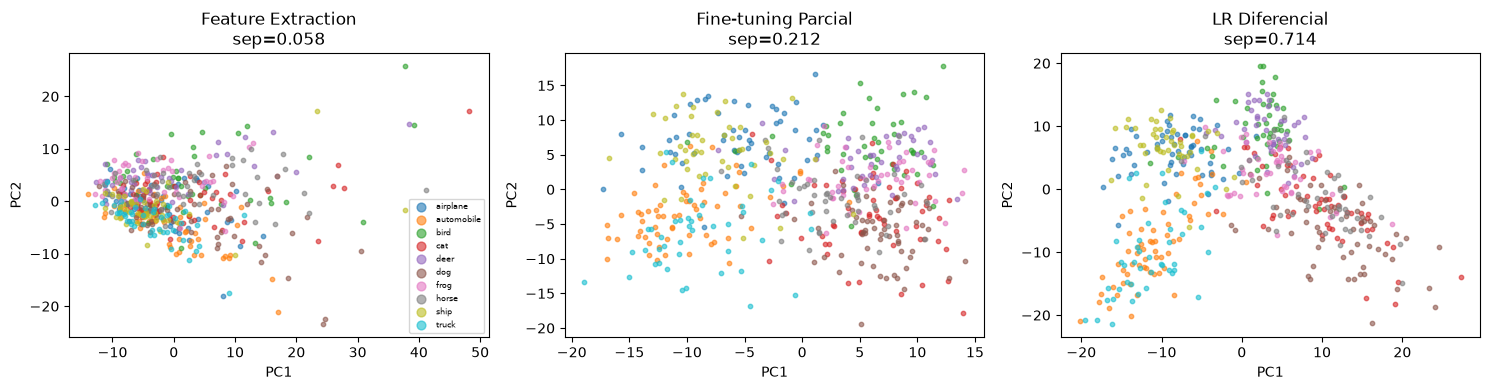

In [16]:
# Visualizacion: proyeccion 2D de los embeddings con PCA manual
def pca_2d(embeddings):
    """PCA manual con SVD para proyectar a 2 dimensiones."""
    X = embeddings - embeddings.mean(0, keepdim=True)
    _, _, Vt = torch.linalg.svd(X, full_matrices=False)
    return (X @ Vt[:2].T)  # (N, 2)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = plt.cm.tab10(np.linspace(0, 1, 10))

for ax, (emb, lab, title) in zip(axes, [
    (emb_fe,  lab_fe,  'Feature Extraction'),
    (emb_pf,  lab_pf,  'Fine-tuning Parcial'),
    (emb_dlr, lab_dlr, 'LR Diferencial'),
]):
    proj = pca_2d(emb).numpy()
    for k in range(10):
        mask = lab.numpy() == k
        ax.scatter(proj[mask, 0], proj[mask, 1],
                   c=[colors[k]], label=CLASSES[k], s=10, alpha=0.6)
    ax.set_title(f'{title}\nsep={separability_ratio(emb,lab):.3f}')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    if ax == axes[0]: ax.legend(fontsize=6, markerscale=2)

plt.tight_layout()
plt.savefig('representaciones_pca.png', dpi=110)
plt.show()


In [17]:
# Verificacion Bloque 4
try:
    assert emb_fe is not None, 'emb_fe no definido'
    assert emb_pf is not None, 'emb_pf no definido'
    assert emb_dlr is not None, 'emb_dlr no definido'
    assert emb_fe.shape[1] == 512, f'Dim incorrecta: {emb_fe.shape[1]}'
    assert not torch.isnan(emb_fe).any(), 'NaN en embeddings FE'
    assert not torch.isnan(emb_pf).any(), 'NaN en embeddings PF'
    assert not torch.isnan(emb_dlr).any(), 'NaN en embeddings DLR'
    assert sep_fe is not None and sep_fe > 0, 'sep_fe debe ser positivo'
    assert sep_pf is not None and sep_pf > 0, 'sep_pf debe ser positivo'
    assert sep_dlr is not None and sep_dlr > 0, 'sep_dlr debe ser positivo'
    _resultados['b4'] = True
    print(f'BLOQUE 4: CORRECTO')
    print(f'  sep_fe={sep_fe:.4f}, sep_pf={sep_pf:.4f}, sep_dlr={sep_dlr:.4f}')
except AssertionError as e:
    _resultados['b4'] = False
    print(f'BLOQUE 4: INCORRECTO\n  {e}')


BLOQUE 4: CORRECTO
  sep_fe=0.0580, sep_pf=0.2124, sep_dlr=0.7141


In [18]:
# Evidencia para la Pregunta 3b:
# cuanto se movio cada grupo de capas respecto a los pesos originales de ImageNet.
#
# IMPORTANTE: se compara sobre named_parameters() y NO sobre state_dict().
# state_dict() incluye los buffers de BatchNorm (running_mean / running_var),
# que se actualizan por media movil en cada forward en modo train() sin importar
# el learning rate ni requires_grad. Medirlos da conclusiones falsas.

ref_p = dict(models.resnet18(weights='IMAGENET1K_V1').named_parameters())

def cambio_relativo(model, prefijo, buffers=False):
    """||W_ft - W_0||_F / ||W_0||_F para todos los parametros bajo `prefijo`."""
    ref = dict(models.resnet18(weights='IMAGENET1K_V1').named_buffers()) if buffers else ref_p
    act = dict(model.named_buffers()) if buffers else dict(model.named_parameters())
    num = den = 0.0
    for nombre, w0 in ref.items():
        if not nombre.startswith(prefijo) or not w0.dtype.is_floating_point:
            continue
        num += (act[nombre].detach().cpu() - w0).pow(2).sum().item()
        den += w0.pow(2).sum().item()
    return (num ** 0.5) / (den ** 0.5) if den > 0 else float('nan')

LRS = {'conv1': 1e-6, 'bn1': 1e-6, 'layer1': 1e-5,
       'layer2': 5e-5, 'layer3': 1e-4, 'layer4': 5e-4}

print('Modelo DLR — cambio relativo de pesos vs ImageNet (solo parametros):')
for g, lr in LRS.items():
    print(f'  {g:7s} lr={lr:<8.0e} rel={cambio_relativo(model_dlr, g):.4e}')

print('\nControl — mismos grupos pero BUFFERS de BatchNorm:')
for g in ['bn1', 'layer4']:
    print(f'  DLR {g:7s} buffers rel={cambio_relativo(model_dlr, g, buffers=True):.4e}')
print(f'  FE  layer4  params  rel={cambio_relativo(model_fe, "layer4"):.4e}   <- congelada: exactamente 0')
print(f'  FE  layer4  buffers rel={cambio_relativo(model_fe, "layer4", buffers=True):.4e}   <- pero las stats de BN si se movieron')

# Escala del desplazamiento en conv1 frente a la cota de Adam
w0 = ref_p['conv1.weight']
d  = dict(model_dlr.named_parameters())['conv1.weight'].detach().cpu() - w0
T, eta = 32 * N_EPOCHS_DLR, 1e-6
print(f'\nconv1: pasos T={T}, lr={eta:.0e}')
print(f'  rms por coordenada  = {d.pow(2).mean().sqrt().item():.4e}')
print(f'  max |delta theta|   = {d.abs().max().item():.4e}')
print(f'  cota deriva  eta*T       = {eta*T:.4e}')
print(f'  camino aleat. eta*sqrt(T) = {eta*T**0.5:.4e}')


Modelo DLR — cambio relativo de pesos vs ImageNet (solo parametros):
  conv1   lr=1e-06    rel=1.0258e-04
  bn1     lr=1e-06    rel=4.6375e-05
  layer1  lr=1e-05    rel=2.8068e-03
  layer2  lr=5e-05    rel=1.9370e-02
  layer3  lr=1e-04    rel=5.3560e-02
  layer4  lr=5e-04    rel=2.3491e-01

Control — mismos grupos pero BUFFERS de BatchNorm:
  DLR bn1     buffers rel=3.8309e-01
  DLR layer4  buffers rel=3.9378e-01
  FE  layer4  params  rel=0.0000e+00   <- congelada: exactamente 0
  FE  layer4  buffers rel=4.3659e-01   <- pero las stats de BN si se movieron

conv1: pasos T=320, lr=1e-06
  rms por coordenada  = 1.3304e-05
  max |delta theta|   = 4.2528e-05
  cota deriva  eta*T       = 3.2000e-04
  camino aleat. eta*sqrt(T) = 1.7889e-05


---
## Bloque 5: Preguntas de análisis (25 pts)

---

### Pregunta 1 (9 pts)

En el Bloque 1, la nueva capa `fc` recibe gradientes pero el backbone no. En el Bloque 2, el gradiente también fluye hacia `layer4`.

**a)** Describa matemáticamente qué ocurre con el gradiente de la pérdida respecto a los parámetros de `layer3` en el Bloque 2. ¿Por qué `requires_grad=False` en `layer3` no significa que el gradiente sea cero matemáticamente, sino que simplemente no se calcula ni se almacena? ¿Qué implicación tiene esto para el cómputo y la memoria?

**b)** En el Bloque 3, `layer1` recibe un learning rate de `1e-6` y la cabeza `1e-3`, una diferencia de 1000×. Usando la fórmula de actualización de Adam:
$$\theta_{t+1} = \theta_t - \eta \frac{\hat{\mathbf{m}}_t}{\sqrt{\hat{\mathbf{v}}_t}+\epsilon}$$
explique cuantitativamente cómo afecta esa diferencia de learning rate a la magnitud del cambio en los pesos de `layer1` versus la cabeza, asumiendo gradientes de magnitud similar en ambas capas.

**c)** Observe sus curvas de convergencia. ¿En qué época el fine-tuning parcial supera a feature extraction? ¿Y el LR diferencial al parcial? Proponga una hipótesis sobre por qué fine-tuning parcial puede converger más lento que feature extraction en las primeras épocas pero alcanzar mejor accuracy final.

**Su respuesta a la Pregunta 1:**

a)

Por la regla de la cadena, el gradiente respecto a los parámetros $W_3$ de layer3 existe matemáticamente:

$$\frac{\partial \mathcal{L}}{\partial W_3} = \frac{\partial \mathcal{L}}{\partial a_4} \cdot \frac{\partial a_4}{\partial a_3} \cdot \frac{\partial a_3}{\partial W_3}$$

donde $a_3, a_4$ son las activaciones de layer3 y layer4. Este valor es en general no nulo. requires_grad=False es una instrucción al motor de autograd de PyTorch: simplemente no construye el grafo computacional para $W_3$ ni almacena $\partial \mathcal{L}/\partial W_3$. El backprop se detiene al llegar a la entrada de layer4 (salida de layer3), porque no hay ningún tensor aguas abajo con requires_grad=True que dependa de $W_3$. La implicación es doble: cómputo reducido (no se ejecutan las operaciones de backprop a través de layer3) y memoria reducida (no se reserva tensor .grad para sus parámetros), sin ningún efecto sobre la corrección matemática del gradiente de layer4.

b)

Bajo Adam, la magnitud del cambio en un parámetro es:

$$|\Delta\theta| = \eta \cdot \left|\frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}\right|$$

Si ambas capas tienen gradientes de magnitud similar, el factor $|\hat{m}_t / (\sqrt{\hat{v}_t} + \epsilon)| \approx C$ es comparable. Entonces:

$$|\Delta\theta_{\text{layer1}}| \approx 10^{-6} \cdot C \qquad |\Delta\theta_{\text{head}}| \approx 10^{-3} \cdot C$$

$$\frac{|\Delta\theta_{\text{head}}|}{|\Delta\theta_{\text{layer1}}|} = \frac{10^{-3}}{10^{-6}} = 1000$$

La cabeza se actualiza 1000× más por paso que layer1. Tras 10 épocas ($\approx 32$ batches cada una), layer1 acumula un desplazamiento total del orden de $320 \times 10^{-6} \cdot C$, prácticamente despreciable respecto a la inicialización ImageNet, mientras que la cabeza converge rápidamente a los 10 logits de CIFAR-10.


c)

**Datos observados.** Accuracy de validación por época (ejecución lineal completa de este notebook, `torch.manual_seed(42)`):

| Época | FE | PF | DLR |
|:---:|:---:|:---:|:---:|
| 1  | 43.20 % | 62.00 % | 73.60 % |
| 2  | 52.20 % | 68.80 % | 75.20 % |
| 3  | 54.40 % | 69.40 % | 74.00 % |
| 4  | 55.20 % | 71.80 % | 77.00 % |
| 5  | 58.40 % | 72.80 % | 77.20 % |
| 6  | 59.20 % | 72.20 % | 78.00 % |
| 7  | **62.40 %** | 72.60 % | **78.60 %** |
| 8  | 58.80 % | **74.80 %** | 76.00 % |
| 9  | 59.20 % | 73.60 % | 77.60 % |
| 10 | 60.80 % | 73.60 % | 75.40 % |

**No hubo cruce en ninguno de los dos casos: el orden queda establecido desde la época 1.** El fine-tuning parcial ya supera a feature extraction en la primera medición de validación (62.00 % vs 43.20 %, +18.8 puntos) y nunca vuelve a quedar por debajo. El LR diferencial supera al parcial también desde la época 1 (73.60 % vs 62.00 %, +11.6 puntos) y mantiene la ventaja las 10 épocas.

**Hipótesis sobre el arranque lento del fine-tuning parcial.** El mecanismo al que apunta la pregunta es la **co-adaptación** entre `layer4` y la nueva cabeza. En la época 0 la cabeza `fc` está inicializada al azar, así que produce logits sin sentido y retropropaga un gradiente esencialmente ruidoso. En feature extraction ese ruido solo afecta a 5,130 parámetros sobre activaciones fijas: `fc` resuelve un problema convexo (regresión logística multinomial sobre features constantes) y converge de inmediato. En fine-tuning parcial ese mismo gradiente ruidoso entra a los 8.4 M de parámetros de `layer4`, desplazando la distribución de activaciones que `fc` está tratando de ajustar. Ambas capas persiguen un blanco móvil y deben alcanzar un equilibrio conjunto antes de progresar; en el peor caso, updates grandes guiados por una cabeza aleatoria degradan features preentrenadas que ya eran buenas.

**Por qué no se observó ese transitorio en esta corrida.** Tres razones concretas:

1. **Resolución de la medición.** Una época son solo 32 batches, y `val_acc` se mide al *final* de la época. La fase en que la cabeza aleatoria manda gradiente sin información dura del orden de decenas de pasos; para cuando se toma la primera medición, ese transitorio ya pasó. Con medición por batch dentro de la época 1 sí sería visible.
2. **El learning rate de PF ya está amortiguado.** PF usa `lr=1e-4`, 10× menor que el `lr=1e-3` de FE. Ese lr conservador es precisamente lo que impide que el gradiente ruidoso inicial desestabilice `layer4`: PF nunca llega a pagar el costo de la co-adaptación de forma visible.
3. **El techo de FE es muy bajo en este setup.** Con 2,000 imágenes de entrenamiento, 5,130 parámetros entrenables y features de ImageNet congeladas, FE está limitado por capacidad desde el primer paso (su mejor época es 62.40 %). PF dispone de 8.4 M de parámetros adaptables, así que domina desde el arranque aunque su optimización sea más difícil.

Se esperaría ver el cruce si (i) se midiera por batch en lugar de por época, (ii) se usara para `layer4` el mismo `lr=1e-3` alto que usa FE, o (iii) se entrenara con muchos más datos, donde el techo de FE deja de ser el factor limitante. De hecho, la receta estándar para evitar ese transitorio —congelar el backbone unas épocas de *warmup* para que la cabeza se estabilice y recién entonces descongelar— existe justamente porque el problema es real cuando el lr es agresivo.

**Lo que sí muestran las curvas es sobreajuste, no lentitud.** El costo de la mayor capacidad aparece por el otro lado:

- **PF:** `train_acc` llega a 99.95 % en la época 10 mientras `val_acc` se estanca en ~74 %.
- **DLR:** `val_loss` sube de 0.761 (época 2) a 1.060 (época 10) mientras `train_loss` baja hasta 0.039 — el modelo sigue memorizando las 2,000 imágenes mucho después de dejar de generalizar. Su mejor accuracy es de la época 7, no de la última.
- **FE** es el único que casi no sobreajusta (`train_acc` 68.75 % contra `val_acc` 60.80 %), justamente por tener solo 5,130 parámetros: es el extremo de alto sesgo y baja varianza del compromiso.

Es decir, la ventaja del fine-tuning en este régimen de datos escasos no es que converja distinto, sino que su techo es más alto; y ese techo viene acompañado de una necesidad real de *early stopping* que feature extraction no tiene.


---
### Pregunta 2 (8 pts)

En la Diapositiva 11 se derivó que LoRA factoriza la actualización de pesos como $\Delta W = BA$ con $B \in \mathbb{R}^{d \times r}$ y $A \in \mathbb{R}^{r \times k}$.

**a)** Para la capa `fc` de ResNet-18 con $d=10$ (clases CIFAR-10) y $k=512$ (features de entrada), calcule el número de parámetros en la actualización completa $\Delta W$ y en la factorización LoRA con $r \in \{1, 2, 4, 8\}$. Para cada valor de $r$, calcule el porcentaje de reducción respecto a la actualización completa.

**b)** LoRA inicializa $B=\mathbf{0}$ y $A \sim \mathcal{N}(0, \sigma^2)$, garantizando que $\Delta W = BA = \mathbf{0}$ al inicio. ¿Qué hubiera pasado si se inicializara también $A=\mathbf{0}$? Justifique en términos del gradiente que recibirían $A$ y $B$ en el primer paso de entrenamiento.

Hint: $\frac{\partial \mathcal{L}}{\partial A} = B^\top \frac{\partial \mathcal{L}}{\partial \Delta W}$ y $\frac{\partial \mathcal{L}}{\partial B} = \frac{\partial \mathcal{L}}{\partial \Delta W} A^\top$.

**Su respuesta a la Pregunta 2:**

**a)**

La capa `fc` tiene $d = 10$ (salidas) y $k = 512$ (entradas).

- **Actualización completa:** $\Delta W \in \mathbb{R}^{10 \times 512}$, es decir $d \cdot k = 10 \times 512 = \mathbf{5{,}120}$ parámetros.
- **LoRA:** $B \in \mathbb{R}^{10 \times r}$ y $A \in \mathbb{R}^{r \times 512}$, es decir $r(d + k) = r(10 + 512) = \mathbf{522\,r}$ parámetros.

| $r$ | Params LoRA $= 522r$ | Params $\Delta W$ | Fracción $522r/5120$ | **Reducción** |
|---|---|---|---|---|
| 1 | 522   | 5,120 | 0.1020 | **89.80 %** |
| 2 | 1,044 | 5,120 | 0.2039 | **79.61 %** |
| 4 | 2,088 | 5,120 | 0.4078 | **59.22 %** |
| 8 | 4,176 | 5,120 | 0.8156 | **18.44 %** |

**Observación importante sobre este caso particular:** LoRA es rentable cuando $r \ll \min(d,k)$. Aquí $\min(d,k) = 10$, así que el punto de equilibrio está en
$$r(d+k) = dk \;\Longrightarrow\; r^* = \frac{dk}{d+k} = \frac{5120}{522} \approx 9.81,$$
es decir que con $r \geq 10$ la factorización usa **más** parámetros que la actualización densa, y además $\operatorname{rank}(\Delta W) \le \min(10, 512) = 10$, por lo que $r = 10$ ya cubre todo el espacio posible de actualizaciones: no hay nada que ganar más allá. Por eso la reducción cae tan rápido ($r=8$ apenas ahorra 18 %). LoRA brilla en matrices donde ambas dimensiones son grandes (p. ej. las proyecciones $4096 \times 4096$ de un Transformer, donde $r=8$ da >99 % de reducción); una cabeza de clasificación de 10 clases es justo el caso donde *no* vale la pena.

**b)**

Si se inicializara $A = \mathbf{0}$ **y** $B = \mathbf{0}$, el modelo quedaría atrapado permanentemente en $\Delta W = \mathbf{0}$. Usando las expresiones del hint, en el primer paso:

$$\frac{\partial \mathcal{L}}{\partial A} = B^\top \frac{\partial \mathcal{L}}{\partial \Delta W} = \mathbf{0}^\top \frac{\partial \mathcal{L}}{\partial \Delta W} = \mathbf{0}$$

$$\frac{\partial \mathcal{L}}{\partial B} = \frac{\partial \mathcal{L}}{\partial \Delta W} A^\top = \frac{\partial \mathcal{L}}{\partial \Delta W} \mathbf{0}^\top = \mathbf{0}$$

Ambos gradientes son exactamente cero, **aunque $\partial \mathcal{L}/\partial \Delta W \neq \mathbf{0}$**. Es decir: la pérdida sí "quiere" mover $\Delta W$, pero la parametrización factorizada no puede transmitir esa señal, porque cada factor recibe su gradiente multiplicado por el otro factor, que vale cero. El punto $(A,B) = (\mathbf{0},\mathbf{0})$ es un **punto silla degenerado** de la reparametrización.

La consecuencia es que la actualización es nula y el estado no cambia: $A_1 = A_0 = \mathbf{0}$, $B_1 = B_0 = \mathbf{0}$, y en el paso $t+1$ se repite exactamente el mismo cálculo. El adaptador nunca despega y entrenar LoRA sería equivalente a no entrenar nada. Ni siquiera Adam rescata la situación: con $g_t = 0$ para todo $t$ se tiene $\hat{m}_t = 0$ y $\hat{v}_t = 0$, de modo que $\eta \hat{m}_t/(\sqrt{\hat{v}_t}+\epsilon) = 0/\epsilon = 0$. (Solo el ruido numérico o un weight decay podrían perturbarlo, y no en una dirección útil.)

La inicialización real ($B = \mathbf{0}$, $A \sim \mathcal{N}(0,\sigma^2)$) resuelve las dos exigencias a la vez:

1. **Arranque idéntico al modelo preentrenado:** $\Delta W = BA = \mathbf{0}$, así que en el paso 0 la red se comporta exactamente como los pesos originales — no se introduce ruido que destruya el conocimiento preentrenado.
2. **Ruptura de simetría:** como $A \neq \mathbf{0}$, en el primer paso $\partial \mathcal{L}/\partial B = (\partial \mathcal{L}/\partial \Delta W) A^\top \neq \mathbf{0}$, así que $B$ se despega de cero. A partir del segundo paso $B \neq \mathbf{0}$ y entonces $\partial \mathcal{L}/\partial A = B^\top (\partial \mathcal{L}/\partial \Delta W) \neq \mathbf{0}$, con lo que ambos factores ya entrenan normalmente.

Por simetría, la elección inversa ($A = \mathbf{0}$, $B \sim \mathcal{N}(0,\sigma^2)$) también funcionaría: lo único inadmisible es que **ambos** factores sean cero simultáneamente.


---
### Pregunta 3 (8 pts)

Compare los ratios de separabilidad de los tres modelos que calculó en el Bloque 4.

**a)** La separabilidad mide qué tan bien separadas están las clases en el espacio de embeddings. Si fine-tuning parcial produce mayor separabilidad que feature extraction, ¿qué implica eso sobre lo que aprendió `layer4` durante el fine-tuning? Conecte su respuesta con la jerarquía de features de la Diapositiva 3: ¿qué tipo de features específicos del dominio CIFAR-10 esperaría que `layer4` haya aprendido que no estaban en los pesos de ImageNet?

**b)** Proponga un experimento concreto para verificar si las capas tempranas de su modelo DLR (con `lr=1e-6`) cambiaron significativamente respecto a los pesos originales de ImageNet. ¿Qué métrica usaría para cuantificar ese cambio y qué resultado esperaría encontrar? Justifique en términos del learning rate diferencial y el número de épocas de entrenamiento.

**Su respuesta a la Pregunta 3:**

**a)**

**Resultados medidos (Bloque 4, 500 imágenes de validación, embeddings de 512-d):**

| Modelo | Ratio de separabilidad | vs. FE | Mejor val acc |
|---|---:|---:|---:|
| Feature extraction | 0.0580 | 1.00× | 62.40 % |
| Fine-tuning parcial | 0.2124 | **3.66×** | 74.80 % |
| LR diferencial | 0.7141 | **12.31×** | 78.60 % |

Sí: el fine-tuning parcial produce **3.66× más separabilidad** que feature extraction.

**Por qué la comparación FE vs. PF aísla exactamente a `layer4`.** Los dos modelos parten de los mismos pesos de ImageNet y mantienen `conv1`, `bn1`, `layer1`, `layer2` y `layer3` congelados e idénticos. La única diferencia en el camino que produce el embedding es que en PF `layer4` sí se entrenó. Como los embeddings se toman a la salida de `avgpool` —es decir, *después* de `layer4` pero *antes* de `fc`— la cabeza no participa en el cálculo. Todo el aumento de 3.66× es atribuible a `layer4` y a nada más.

**Qué implica eso sobre lo que aprendió `layer4`.** Que no se limitó a "ajustarse": reorganizó geométricamente el espacio de representación. El ratio de Fisher sube porque los centroides de clase se alejan entre sí *y* porque la dispersión dentro de cada clase se comprime. Y como se mide sobre 500 imágenes de validación que el modelo nunca vio, no es memorización: `layer4` aprendió una transformación que generaliza a datos nuevos del dominio.

**Conexión con la jerarquía de features (Diapositiva 3).** La jerarquía va de universal a específico:

- `conv1` / `layer1` — bordes, colores, filtros tipo Gabor. Son universales para imágenes naturales; transfieren perfecto y no hay nada que reaprender.
- `layer2` / `layer3` — texturas y motivos compuestos. Parcialmente específicos del dominio.
- `layer4` — partes de objeto y configuraciones específicas de clase. **Es el nivel más específico del dominio**, y por eso es el que más gana al descongelarse.

Eso explica el reparto de las mejoras: descongelar solo `layer4` sube de 62.40 % a 74.80 % (+12.4 pts), mientras que además descongelar todo lo demás con LRs diminutos solo agrega 3.8 pts más. Casi toda la especificidad de dominio de ResNet-18 vive en `layer4`.

**Features específicos de CIFAR-10 que esperaría que `layer4` haya aprendido** (y que no podían estar en los pesos de ImageNet):

1. **Robustez a la pérdida de resolución.** CIFAR-10 es 32×32 reescalado a 64×64; ImageNet se entrena a 224×224. Los detectores de `layer4` preentrenados esperan textura fina —pelaje, plumas, granulado de superficie— que sencillamente no existe a 32 px. `layer4` tiene que reanclarse en siluetas, proporciones globales y contraste figura/fondo.
2. **Colapso de la granularidad de ImageNet.** ImageNet tiene ~120 razas de perro como clases *distintas*, así que `layer4` preentrenada dedica capacidad activa a ejes que separan husky de malamute. Para CIFAR-10 esa varianza es puro ruido intra-clase: hay que colapsarla dentro de "dog" (lo que reduce el denominador del ratio) y en su lugar amplificar el eje cat↔dog. Este es probablemente el aporte más grande al aumento de separabilidad.
3. **Ejes discriminativos que ImageNet no prioriza.** CIFAR-10 mezcla 4 vehículos (airplane, automobile, ship, truck) y 6 animales. Separar automobile de truck, o deer de horse, exige ejes de forma global (proporción cabina/carrocería, silueta de astas y cuello) que ImageNet no necesita destacar porque los resuelve por contexto de escena en alta resolución.
4. **Objeto centrado sobre fondo poco informativo.** En CIFAR-10 el objeto ocupa casi todo el marco y el fondo aporta poco. `layer4` puede dejar de gastar capacidad modelando contexto de escena —crítico en ImageNet, inútil aquí— y concentrarla en el objeto.

**Un matiz sobre la relación separabilidad ↔ accuracy.** El orden de los ratios (0.0580 < 0.2124 < 0.7141) coincide con el orden de los accuracies (62.40 % < 74.80 % < 78.60 %), pero la relación es fuertemente no lineal: DLR **triplica** la separabilidad de PF y solo gana 3.8 puntos de accuracy. La interpretación es que una vez que las clases son linealmente separables, seguir compactándolas no compra accuracy: el error restante está en ejemplos genuinamente ambiguos a 32 px (cat/dog, automobile/truck) y en el sobreajuste a 2,000 imágenes. Vale notar además que este ratio de Fisher es isotrópico —usa distancias euclidianas y no la covarianza intra-clase completa—, así que es un buen proxy de la separabilidad lineal, no una medida exacta de ella.

---

**b)**

**Experimento propuesto.** Comparar los pesos del modelo DLR ya entrenado contra una ResNet-18 recién cargada con los pesos originales de ImageNet, grupo por grupo. *(Implementado y ejecutado en la celda de código que sigue a la verificación del Bloque 4; los números de abajo son su salida.)*

**Métrica: distancia de Frobenius relativa.**

$$\rho_{\text{grupo}} = \frac{\lVert W_{\text{ft}} - W_0 \rVert_F}{\lVert W_0 \rVert_F}$$

Es adimensional, así que permite comparar capas de tamaños muy distintos (`conv1` tiene 9,408 parámetros y `layer4` tiene 8.4 M) y se lee directo como fracción de cambio.

```python
ref_p = dict(models.resnet18(weights='IMAGENET1K_V1').named_parameters())

def cambio_relativo(model, prefijo):
    act = dict(model.named_parameters())   # OJO: named_parameters(), no state_dict()
    num = den = 0.0
    for nombre, w0 in ref_p.items():
        if not nombre.startswith(prefijo):
            continue
        num += (act[nombre].detach().cpu() - w0).pow(2).sum().item()
        den += w0.pow(2).sum().item()
    return (num ** 0.5) / (den ** 0.5)
```

**Resultado esperado: cambio monótono creciente con el learning rate, y capas tempranas prácticamente intactas.** Medido:

| Grupo | Learning rate | $\rho$ medido | Interpretación |
|---|---:|---:|---|
| `conv1` | 1e-6 | 1.026e-04 | **0.010 %** — intacta |
| `bn1`   | 1e-6 | 4.638e-05 | **0.005 %** — intacta |
| `layer1`| 1e-5 | 2.807e-03 | 0.28 % |
| `layer2`| 5e-5 | 1.937e-02 | 1.9 % |
| `layer3`| 1e-4 | 5.356e-02 | 5.4 % |
| `layer4`| 5e-4 | 2.349e-01 | **23 %** — reescrita |

La hipótesis se confirma: `conv1` cambió un 0.010 %, es decir que a efectos prácticos **sigue siendo el extractor de ImageNet sin tocar**, mientras que `layer4` se reescribió en un 23 %.

**Justificación cuantitativa (por qué esperaba ese orden de magnitud).** Bajo Adam el paso por coordenada es $|\Delta\theta| = \eta\,|\hat{m}_t/(\sqrt{\hat{v}_t}+\epsilon)| \lesssim \eta$, porque el cociente está normalizado y satura en ±1 cuando el gradiente es consistente. Con $T = 32 \text{ batches} \times 10 \text{ épocas} = 320$ pasos y $\eta = 10^{-6}$, la cota si *todos* los pasos apuntaran en la misma dirección es

$$|\Delta\theta|_{\max} \lesssim \eta\,T = 320 \times 10^{-6} = 3.2 \times 10^{-4}$$

Medido en `conv1`: $\max|\Delta\theta| = 4.25\times10^{-5}$, o sea que respeta la cota con 7.5× de holgura. Más interesante es el rms por coordenada, $1.33\times10^{-5}$, comparado contra los dos regímenes posibles:

| Régimen | Predicción | vs. medido ($1.33\times10^{-5}$) |
|---|---:|---|
| Deriva consistente, $\eta T$ | $3.2\times10^{-4}$ | 24× **mayor** que lo medido |
| Camino aleatorio, $\eta\sqrt{T}$ | $1.79\times10^{-5}$ | mismo orden (0.74×) |

El desplazamiento escala como $\sqrt{T}$ y no como $T$: el gradiente sobre `conv1` **cambia de signo entre pasos y se cancela**. La lectura es que `conv1` ya está esencialmente en un óptimo para estas features —bordes y colores son universales, Diapositiva 3—, así que ni siquiera "quiere" moverse; el `lr=1e-6` solo garantiza que no lo haga aunque quisiera.

**Trampa metodológica que hay que evitar.** Es obligatorio usar `named_parameters()` y **no** `state_dict()`. `state_dict()` incluye los *buffers* de BatchNorm (`running_mean`, `running_var`), que el optimizador no toca: se actualizan por media móvil en cada forward en modo `train()`, sin importar el learning rate ni `requires_grad`. Medirlos da conclusiones falsas:

| | parámetros | buffers de BN |
|---|---:|---:|
| DLR `bn1` | 4.638e-05 | 3.831e-01 |
| DLR `layer4` | 2.349e-01 | 3.938e-01 |
| **FE `layer4` (congelada)** | **0.000e+00** | **4.366e-01** |

La última fila es el control decisivo: en feature extraction `layer4` tiene `requires_grad=False` y sus parámetros cambian **exactamente 0** — pero sus estadísticas de BatchNorm se movieron un 44 %, porque `train_epoch()` llama a `model.train()`. Midiendo sobre `state_dict()` uno concluiría que un backbone completamente congelado "cambió un 44 %".

(Ese movimiento de las running stats no es un artefacto inofensivo: es el desplazamiento de dominio ImageNet→CIFAR-10 quedando registrado en las estadísticas de activación, y **sí** afecta la inferencia porque en `eval()` se usan esos buffers. Para congelar el backbone de verdad habría que además ponerlo en `.eval()` durante el entrenamiento.)

**Controles y métrica complementaria.**

- **Control de sanidad:** la fila `FE layer4 params = 0.000e+00` cumple exactamente esa función — verifica que la comparación no arrastre diferencias espurias por orden de claves o dtype, porque sobre una capa que demostrablemente no se entrenó da cero exacto.
- **Métrica complementaria:** similitud coseno filtro por filtro en `conv1` (los 64 filtros de 7×7×3), o graficar los 64 filtros del modelo original y del DLR lado a lado. Con un cambio relativo de $10^{-4}$ deben verse idénticos a simple vista, lo que confirma visualmente lo que dice el número.


---
## Verificación automática (75 pts de código)

In [19]:
print('='*60)
print('  VERIFICACION AUTOMATICA — LABORATORIO 6')
print('='*60)

_PUNTOS = {
    'b1': ('B1 Feature extraction (congelado correcto)',  20),
    'b2': ('B2 Fine-tuning parcial (layer4 descongelada)', 20),
    'b3': ('B3 LR diferencial (grupos y LRs correctos)',  20),
    'b4': ('B4 Embeddings y separabilidad',               15),
}

total = 0
for key, (nombre, pts) in _PUNTOS.items():
    ok  = _resultados.get(key, False)
    p   = pts if ok else 0
    total += p
    estado = 'CORRECTO' if ok else 'PENDIENTE'
    print(f'  {estado:10s} | {nombre:44s} | {p:2d}/{pts}')

print('-'*60)
print(f'  Subtotal codigo:      {total}/75 pts')
print(f'  Preguntas de analisis: __/25 pts  (calificacion manual)')
print('-'*60)
print(f'  TOTAL: __/100 pts')
print('='*60)


  VERIFICACION AUTOMATICA — LABORATORIO 6
  CORRECTO   | B1 Feature extraction (congelado correcto)   | 20/20
  CORRECTO   | B2 Fine-tuning parcial (layer4 descongelada) | 20/20
  CORRECTO   | B3 LR diferencial (grupos y LRs correctos)   | 20/20
  CORRECTO   | B4 Embeddings y separabilidad                | 15/15
------------------------------------------------------------
  Subtotal codigo:      75/75 pts
  Preguntas de analisis: __/25 pts  (calificacion manual)
------------------------------------------------------------
  TOTAL: __/100 pts
